## Install Required Libraries

In [1]:
! pip install fastapi uvicorn pydantic typing numpy pinecone PyMuPDF python-dotenv supabase langchain-openai langchain langchain_text_splitters langgraph langchain_core langchain_community semanticscholar beautifulsoup4 asyncio fastmcp pypdf fastmcp chromadb langchain_huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.9/745.9 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.8/473.8 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.8/376.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.5/329.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

## Utils

In [1]:
HF_TOKEN = ""

**Generator**

In [2]:
from transformers import pipeline

pipe = pipeline("text-generation", model="google/gemma-3-1b-it", token = HF_TOKEN)

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Device set to use cuda:0


**Embedding Gemma**

In [4]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("google/embeddinggemma-300m", token = HF_TOKEN)

modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/18.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

3_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

**Local Vector DB**

In [5]:
import chromadb

chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name="Advanced_RAG")

**Text Splitters**

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=50)

**Tools: Get_Embeddings, Rerank, curated_index**

In [35]:
url = "" # Locally Hosted MCP Server

In [8]:
from fastmcp import Client
import numpy as np

class MCPHelper:
    def __init__(self, url: str):
        self.url = url

    async def call(self, tool_name: str, params: dict):
        async with Client(self.url) as client:
            results = await client.call_tool(tool_name, params)
            results = results.data

            # Normalize numpy types
            if isinstance(results, np.ndarray) and results.shape == ():
                results = results.item()

            if not isinstance(results, (list, dict, str)):
                results = [results]

            return results

mcp = MCPHelper(url)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
async def get_embeddings(data: list[str]):
  return await mcp.call("embeddings", {"data": data})

async def curated_index(data, query):
  return await mcp.call("curate", {"data": data, "query": query})

async def rerank_index(data, query):
  return await mcp.call("rerank", {"data": data, "query": query})

**Upsert**

In [10]:
def upsert(texts, num:int):
  embeds = embedder.encode(texts)
  collection.upsert(
      embeddings = embeds,
      ids= [f"id{num + i}" for i in range(len(texts))],
      documents = texts
  )

**Structured Output**

In [11]:
import json, re

def extract_json(text: str):
    text = text.strip()

    try:
        return json.loads(text)
    except:
        pass

    # Extract { ... } Block
    match = re.search(r"\{[\s\S]*\}", text)
    if match:
        return json.loads(match.group(0))

    raise ValueError(f"Failed to extract JSON from:\n{text}")

**UPSERT**

In [12]:
import json

papers = {}

splited_num = 0
with open("qasper_papers.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        paper = json.loads(line)
        print(f"------------------------------ UPSERTED [{i}][148]")

        splited_text = text_splitter.split_text(paper[list(paper)[0]])

        upsert(splited_text, splited_num)
        splited_num += len(splited_text)

------------------------------ UPSERTED [0][148]
------------------------------ UPSERTED [1][148]
------------------------------ UPSERTED [2][148]
------------------------------ UPSERTED [3][148]
------------------------------ UPSERTED [4][148]
------------------------------ UPSERTED [5][148]
------------------------------ UPSERTED [6][148]
------------------------------ UPSERTED [7][148]
------------------------------ UPSERTED [8][148]
------------------------------ UPSERTED [9][148]
------------------------------ UPSERTED [10][148]
------------------------------ UPSERTED [11][148]
------------------------------ UPSERTED [12][148]
------------------------------ UPSERTED [13][148]
------------------------------ UPSERTED [14][148]
------------------------------ UPSERTED [15][148]
------------------------------ UPSERTED [16][148]
------------------------------ UPSERTED [17][148]
------------------------------ UPSERTED [18][148]
------------------------------ UPSERTED [19][148]
----------

In [13]:
pip install rank_bm25

**BUILD BM25 INDEX**

In [14]:
from rank_bm25 import BM25Okapi

tokenized_docs = []
full_texts = []
with open("qasper_papers.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        paper = json.loads(line)

        splited_text = text_splitter.split_text(paper[list(paper)[0]]) # Split Large Papers - STEP 1

        for text in splited_text:
          full_texts.append(text.lower()) # Add into list of chunks - STEP 2
          tokenized_docs.append(text.lower().split()) # Also add thee tokenized version of each text

bm25_index = BM25Okapi(tokenized_docs)

In [ ]:
query = "What was this result for ?"

In [ ]:
len(tokenized_docs)

26263

In [ ]:
len(full_texts)

26263

In [ ]:
sparse_scores = bm25_index.get_scores(query.split())
sparse_top_idx = sparse_scores.argsort()[-5:][::-1]

sparse_results = [full_texts[i] for i in sparse_top_idx]

## Nodes

**Prompts**

In [15]:
generate_prompt = """
  You are an AI assistant.

  Answer the question strictly based on the provided context.

"""

agent = """
You are an ai assistant. for every output return the answer as of format:


type: "ASSISTANT"  <--- keep string intact
heading: <heading of your answer>
content: <your answer>

User Query {{query}}
"""

generate_queries_prompt = """
  You are a specialist in query decomposition and retrieval augmentation.

  Given:
  - Original Query
  - Step-back Query
  - Relevant retrieved Chunks

  Generate multiple sub-queries where:
  - each sub-query is grounded in the chunk content
  - each is distinct from the others
  - each blends the original + step-back intent
  - each is specific to its associated chunk

  Respond ONLY using a JSON object as follows:

  {
    "queries": [
      "<sub-query for chunk 1>",
      "<sub-query for chunk 2>",
      ...
    ]
  }
"""

query_router_prompt = """
  You are a routing module inside a Retrieval-Augmented Generation (RAG) pipeline.

  You must classify the user's query into one of two categories:

  1) "DIRECT"
  When the query can be answered from common knowledge, general reasoning,
  or does not require specific external facts, data, sources, or documents.

  2) "RETRIEVE"
  When answering the query correctly requires:
  - domain-specific knowledge,
  - definitions from external texts,
  - factual grounding,
  - data not commonly known,
  - or information that is likely stored in the knowledge base.
  This includes scientific concepts, research questions, paper contents, and terminology.

  CRITICAL:
  If the query references a concept, a term, a fact, a research idea,
  or anything that would benefit from the vector database of Qasper papers,
  you MUST choose "RETRIEVE".

  Respond using EXACTLY this JSON structure, with no explanation:

  {
    "decision": "DIRECT" or "RETRIEVE"
  }
"""

simple_generator_prompt = """
  You are an AI assistant.

  Answer the question clearly.
"""

step_back_prompt = """
  You are an AI assistant that generates broader, more general reformulations of queries.

  Goal:
  Create a more general "step-back" version of the original query.
  This broader query should improve context retrieval in a RAG system.
"""

**State**

In [16]:
from pydantic import BaseModel
from typing import TypedDict, List

class GenerativeModel(BaseModel):
  type: str
  heading: str
  content: str

class GenerateQueries(BaseModel):
  queries: list[str]

# Node: Query Router
class QueryRouter(BaseModel):
  decision: str

class State(TypedDict):
  decision: str
  query: str
  context: List[str]
  answer: str
  queries: List[str]
  step_back: str

**Nodes**

In [17]:
# ---------------------------------
# ADVANCED RAG NODE: Query Enhancement nodes
#----------------------------------
async def step_back(state:State):
    """
    This helps the system gather more context and background for better retrieval later.
    """
    output = pipe([
        {"role":"system", "content":step_back_prompt},
        {"role":"user", "content":f"Original Query: {state['query']}"}
    ])


    return {"step_back":output[0]['generated_text'][-1]['content']}

async def speciallized_queries_generation(state:State):
    """
    Generate speciallized Queryies
    """
    contexts = "\n\n".join([doc for doc in state['context']])
    output = pipe([
        {"role":"system", "content":generate_queries_prompt},
        {"role":"user", "content":f"Input \n  Original Query: {state['query']} \n Step-Back Query: {state['step_back']} \n Relevant Chunks: {contexts}"}
    ])

    response = GenerateQueries.model_validate(
        extract_json(output[0]['generated_text'][-1]['content'])
    )

    state["context"] = []
    return {"queries":response.queries}

In [18]:
# ---------------------------------
# ADVANCED RAG NODE: Post Retreiver
# ---------------------------------`
async def filter_results(state:State):
    curated = await curated_index(state['context'], state['query']) # > Result Indexes of relevent docs
    state['context'] = [state['context'][idx] for idx in curated]
    return state



async def re_rank_results(state:State):
    re_ranked = await rerank_index(state['context'],state['query'])
    state['context'] = [doc for doc, scores in sorted(re_ranked)][:15] # Only top-10 results

    return state

In [19]:
from langgraph.config import get_stream_writer
import json

# ---------------------------------
# ADVANCED RAG NODE: Query Router
# ---------------------------------
async def router_query(state:State):
    """
      Should User's query requires external retreival
    """
    output = pipe([
        {"role":"system", "content":query_router_prompt},
        {"role":"user", "content":f"Now evaluate this user query: \n {state['query']}"}
    ])

    response = QueryRouter.model_validate(
        extract_json(output[0]['generated_text'][-1]['content'])
    )

    return {"decision":response.decision}

async def general_chat(state:State):
    try:

        output = pipe([
          {"role":"system", "content":simple_generator_prompt},
          {"role":"user", "content":f"Question: \n {state['query']}"}
        ])

        return {"answer":output[0]['generated_text'][-1]['content']}

    except Exception as e:
        return {"answer": str(e)}

In [20]:
#----------------------------------
# NODE: Reterive               TODO: Hybrid Searching
#----------------------------------

async def reterive(state:State, config):
    try:
        context = collection.query(
          query_embeddings = embedder.encode(state['query']),
          n_results = 10,
          include = ["documents", "distances"]
        )['documents']

        return {"context":context[0]}

    except Exception as e:
        return {"context": []}

async def reterive_queries(state:State, config):
    try:
        Context = []
        for query in state['queries']:
          cont = collection.query(
            query_embeddings = embedder.encode(state['query']),
            n_results = 10,
            include = ["documents", "distances"]
          )['documents'][0]

          for d in cont:
            Context.append(d)

          sparse_scores = bm25_index.get_scores(state['query'].split())
          sparse_top_idx = sparse_scores.argsort()[-5:][::-1] # top 5 sparse results

          sparse_results = [full_texts[i] for i in sparse_top_idx]

          for r in sparse_results:
            Context.append(r)

        return {"context":list(set(Context))}

    except Exception as e:
        return {"context": []}

In [21]:
#----------------------------------
# NODE: Generative
#----------------------------------
async def generate(state:State):
    try:
        docs_content = "\n\n".join(state['context'])

        output = pipe([
          {"role":"system", "content":generate_prompt},
          {"role":"user", "content":f"Context: {docs_content} \n\n Question: {state['query']}"}
        ])

        return {"answer":output[0]['generated_text'][-1]['content']}
    except Exception as e:
        return {"answer": str(e)}

In [22]:
def query_router_conditional(state:State):
    return state['decision']

## AdvancedRAG

In [23]:
from langgraph.graph import StateGraph, START, END

advanced_rag_graph =(
    StateGraph(State)
    .add_node("router_query",router_query)
    .add_node("step_back", step_back)
    .add_node("queries", speciallized_queries_generation)
    .add_node("filter_results", filter_results)
    .add_node("re_rank_results", re_rank_results)
    .add_node("general_chat",general_chat)
    .add_node("reterive",reterive)
    .add_node("reterive_queries",reterive_queries)
    .add_node("generate",generate)
    .add_edge(START, "step_back")
    .add_edge("step_back","reterive")
    .add_edge("reterive","queries")
    .add_edge("queries","reterive_queries")
    .add_edge("reterive_queries","re_rank_results")
    .add_edge("re_rank_results","generate")
    .add_edge("generate",END)
    .compile()
)

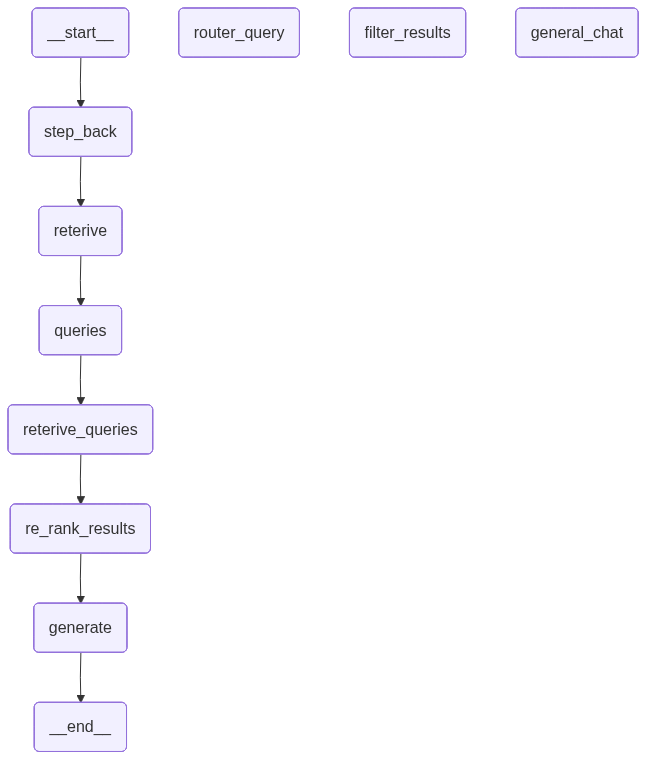

In [24]:
advanced_rag_graph

In [ ]:
res = await advanced_rag_graph.ainvoke({"query":"Hii"})

In [ ]:
res

{'decision': 'DIRECT',
 'query': 'Hii',
 'answer': 'Hello! How can I help you today?'}

In [25]:
res = await advanced_rag_graph.ainvoke({"query":"How are relations used to propagate polarity?"})

In [26]:
res

{'query': 'How are relations used to propagate polarity?',
 'context': ['In this paper, we proposed to use discourse relations to effectively propagate polarities of affective events from seeds. Experiments show that, even with a minimal amount of supervision, the',
  'We note that INLINEFORM0 promotes relations INLINEFORM1 strongly implying INLINEFORM2 (the numerator) and demotes those implied by some other relation in the same neighborhood (the denominator). In',
  'approaches for implicit discourse relations recognition.',
  "corpus. As illustrated in Figure FIGREF1, our key idea is that we can exploit discourse relations BIBREF4 to efficiently propagate polarity from seed predicates that directly report one's emotions",
  "corpus. as illustrated in figure figref1, our key idea is that we can exploit discourse relations bibref4 to efficiently propagate polarity from seed predicates that directly report one's emotions",
  'in this paper, we proposed to use discourse relations to effe

## Prepare Evaluation Data

**Get All Answers**

In [27]:
import os
os.listdir()

['.config',
 'qasper_mini_advanced_rag_hybridr3.jsonl',
 'qasper_papers.jsonl',
 'qasper_qa(1).jsonl',
 'sample_data']

In [28]:
import json
Questions = []

with open("qasper_mini_advanced_rag_hybridr3.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        qa = json.loads(line)
        Questions.append(qa)

In [29]:
Questions[1]

{'input': 'What are the results?',
 'expected_output': 'Using all data to train: AL -- BiGRU achieved 0.843 accuracy, AL -- BERT achieved 0.863 accuracy, AL+CA+CO -- BiGRU achieved 0.866 accuracy, AL+CA+CO -- BERT achieved 0.835, accuracy, ACP -- BiGRU achieved 0.919 accuracy, ACP -- BERT achived 0.933, accuracy, ACP+AL+CA+CO -- BiGRU achieved 0.917 accuracy, ACP+AL+CA+CO -- BERT achieved 0.913 accuracy. \nUsing a subset to train: BERT achieved 0.876 accuracy using ACP (6K), BERT achieved 0.886 accuracy using ACP (6K) + AL, BiGRU achieved 0.830 accuracy using ACP (6K), BiGRU achieved 0.879 accuracy using ACP (6K) + AL + CA + CO.',
 'meta_data': {'context_id': '1909.00694',
  'evidence': ['FLOAT SELECTED: Table 4: Results for small labeled training data. Given the performance with the full dataset, we show BERT trained only with the AL data.',
   'FLOAT SELECTED: Table 3: Performance of various models on the ACP test set.',
   'We trained the model with the following four combinations o

In [34]:
for i in range(len(Questions)):
  if 'outputs' not in Questions[i]:

    try:
      res = await advanced_rag_graph.ainvoke({"query":Questions[i]['input']})

      if 'context' in res:
        context = res['context']
      else:
        context = []

      Questions[i]['outputs'] = {"query":res['query'], "answer":res['answer'], "context":context}
    except Exception as e:
      print(e)

  if i%10 == 0:
    print(f"|-------------------------------- [{i}]")

|-------------------------------- [0]
|-------------------------------- [10]
|-------------------------------- [20]
|-------------------------------- [30]
|-------------------------------- [40]
|-------------------------------- [50]
|-------------------------------- [60]
|-------------------------------- [70]
|-------------------------------- [80]
|-------------------------------- [90]
|-------------------------------- [100]
|-------------------------------- [110]
|-------------------------------- [120]


**Fix Missing Rows**

In [32]:
for q in Questions:
  if 'outputs' not in q:
    print(q)

In [33]:
with open("qasper_mini_advanced_rag_hybridr.jsonl", "w") as f:
    for row in Questions:
        f.write(json.dumps(row) + "\n")